# CircLS pipeline on a paper benchmark: toffoli_n3

QASMBench toffoli_n3 (7 T gates) → NWQEC (pi/8 + pi/4 rotations) →
Y-free → **CircLS PPM sequence under the Y-state approximation** →
placement + routing (3D structure) → stim → measured LER
(PyMatching, matching the paper's PM column for Table 3).  This is the paper's Table 3 Clifford proxy: |Y> stands in
for |T>, exercising the lattice-surgery structure and LER without
claiming non-Clifford logic.
Artifacts land in `data/`, `figures/`, `stim/`, `blockgraph/`.

## 1. The logical circuit: QASMBench toffoli_n3 (7 T gates)

In [1]:
import pathlib, sys
HERE = pathlib.Path.cwd()
ROOT = HERE.parents[2]
for p in (str(ROOT), str(ROOT / "experiments"), str(HERE.parents[1] / "tools")):
    if p not in sys.path:
        sys.path.insert(0, p)
for sub in ("data", "figures", "stim"):
    (HERE / sub).mkdir(exist_ok=True)

from benchsuite import tclass_suite
case = {c.name: c for c in tclass_suite()}["toffoli_n3"]
qasm = case.qasm
pathlib.Path("data/1_toffoli_n3.qasm").write_text(qasm)
print(qasm)

OPENQASM 2.0;
include "qelib1.inc";

qreg a[3];
creg c[3];

x a[0];
x a[1];
h a[2];
cx a[1],a[2];
tdg a[2];
cx a[0],a[2];
t a[2];
cx a[1],a[2];
tdg a[2];
cx a[0],a[2];
tdg a[1];
t a[2];
cx a[0],a[1];
h a[2];
tdg a[1];
cx a[0],a[1];
t a[0];
s a[1];
measure a[0] -> c[0];
measure a[1] -> c[1];
measure a[2] -> c[2];



## 2. NWQEC output: Pauli product rotations + terminal measurements (PBC)

In [2]:
from circls.interop.nwqec.frontend import load_pbc
from nb_helpers import show_ops, save_ops
pbc = load_pbc(qasm, keep_cx=True)
save_ops(pbc, "data/2_toffoli_n3_nwqec_pbc.txt")
show_ops(pbc, limit=14, tail=8)

$(\mathbb{1} \otimes Z \otimes Z)_{-\pi/8}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes Y)_{\pi/4}$  
$(Z \otimes \mathbb{1} \otimes Z)_{-\pi/8}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes X)_{-\pi/4}$  
$(\mathbb{1} \otimes Z \otimes Z)_{-\pi/8}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes Y)_{-\pi/8}$  
$(Z \otimes \mathbb{1} \otimes Z)_{-\pi/4}$  
$(\mathbb{1} \otimes Z \otimes \mathbb{1})_{\pi/8}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes X)_{\pi/4}$  
$(Z \otimes X \otimes \mathbb{1})_{\pi/8}$  
$(\mathbb{1} \otimes Y \otimes \mathbb{1})_{-\pi/4}$  
$(Z \otimes X \otimes \mathbb{1})_{\pi/8}$  
$(Z \otimes \mathbb{1} \otimes \mathbb{1})_{-\pi/4}$  
$-Z \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes Z \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes Z$ measurement

## 3. Y-free rewrite

In [3]:
from circls.interop.ir.yfree import to_y_free
yfree = to_y_free(pbc)
save_ops(yfree, "data/3_toffoli_n3_yfree_ppr.txt")
show_ops(yfree, limit=4, tail=4)

$(\mathbb{1} \otimes Z \otimes Z)_{\pi/8}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes Z)_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes X)_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes Z)_{-\pi/4}$  
... (22 ops total, full list in data/)  
$(Z \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$-Z \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes Z \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes Z$ measurement

## 4. CircLS compilation (Y-state approximation): the executed PPM sequence

In [4]:
import contextlib, io
from circls.pipeline import compile_qasm
from ablation import compile_kwargs
from nb_helpers import ppm_step_lines
KW = compile_kwargs("full", case)

def compile_d(d):
    with contextlib.redirect_stdout(io.StringIO()):
        return compile_qasm(case.qasm, distance=d, t_as_s=True, **KW)

cp3 = compile_d(3)
steps = cp3.experiment.ppm_sequence
lines = ppm_step_lines(steps)
pathlib.Path("data/4_toffoli_n3_ppm_sequence.txt").write_text("\n".join(lines) + "\n")
print(f"{len(steps)} executed PPMs; y0..y6 are the |Y> ancillas standing in "
      f"for the 7 T states (Y-state approximation)")
print("\n".join(ppm_step_lines(steps)))

7 executed PPMs; y0..y6 are the |Y> ancillas standing in for the 7 T states (Y-state approximation)
PPM 0: q0.Z  y0.Z
PPM 1: q1.Z  q2.X  y1.Z
PPM 2: q0.Z  q1.Z  q2.X  y2.Z
PPM 3: q0.Z  q2.X  y3.Z
PPM 4: q1.Z  y4.Z
PPM 5: q0.Z  q1.Z  y5.Z
PPM 6: q2.X  y6.Z


## 5. Placement, routed ancilla paths, and the 3D spacetime structure

10 patches placed, 7 PPM steps (7 joint) routed; full detail in 5_toffoli_n3_placement_routing.json


3D structure: 5_toffoli_n3_spacetime.png (110.7 blocks)


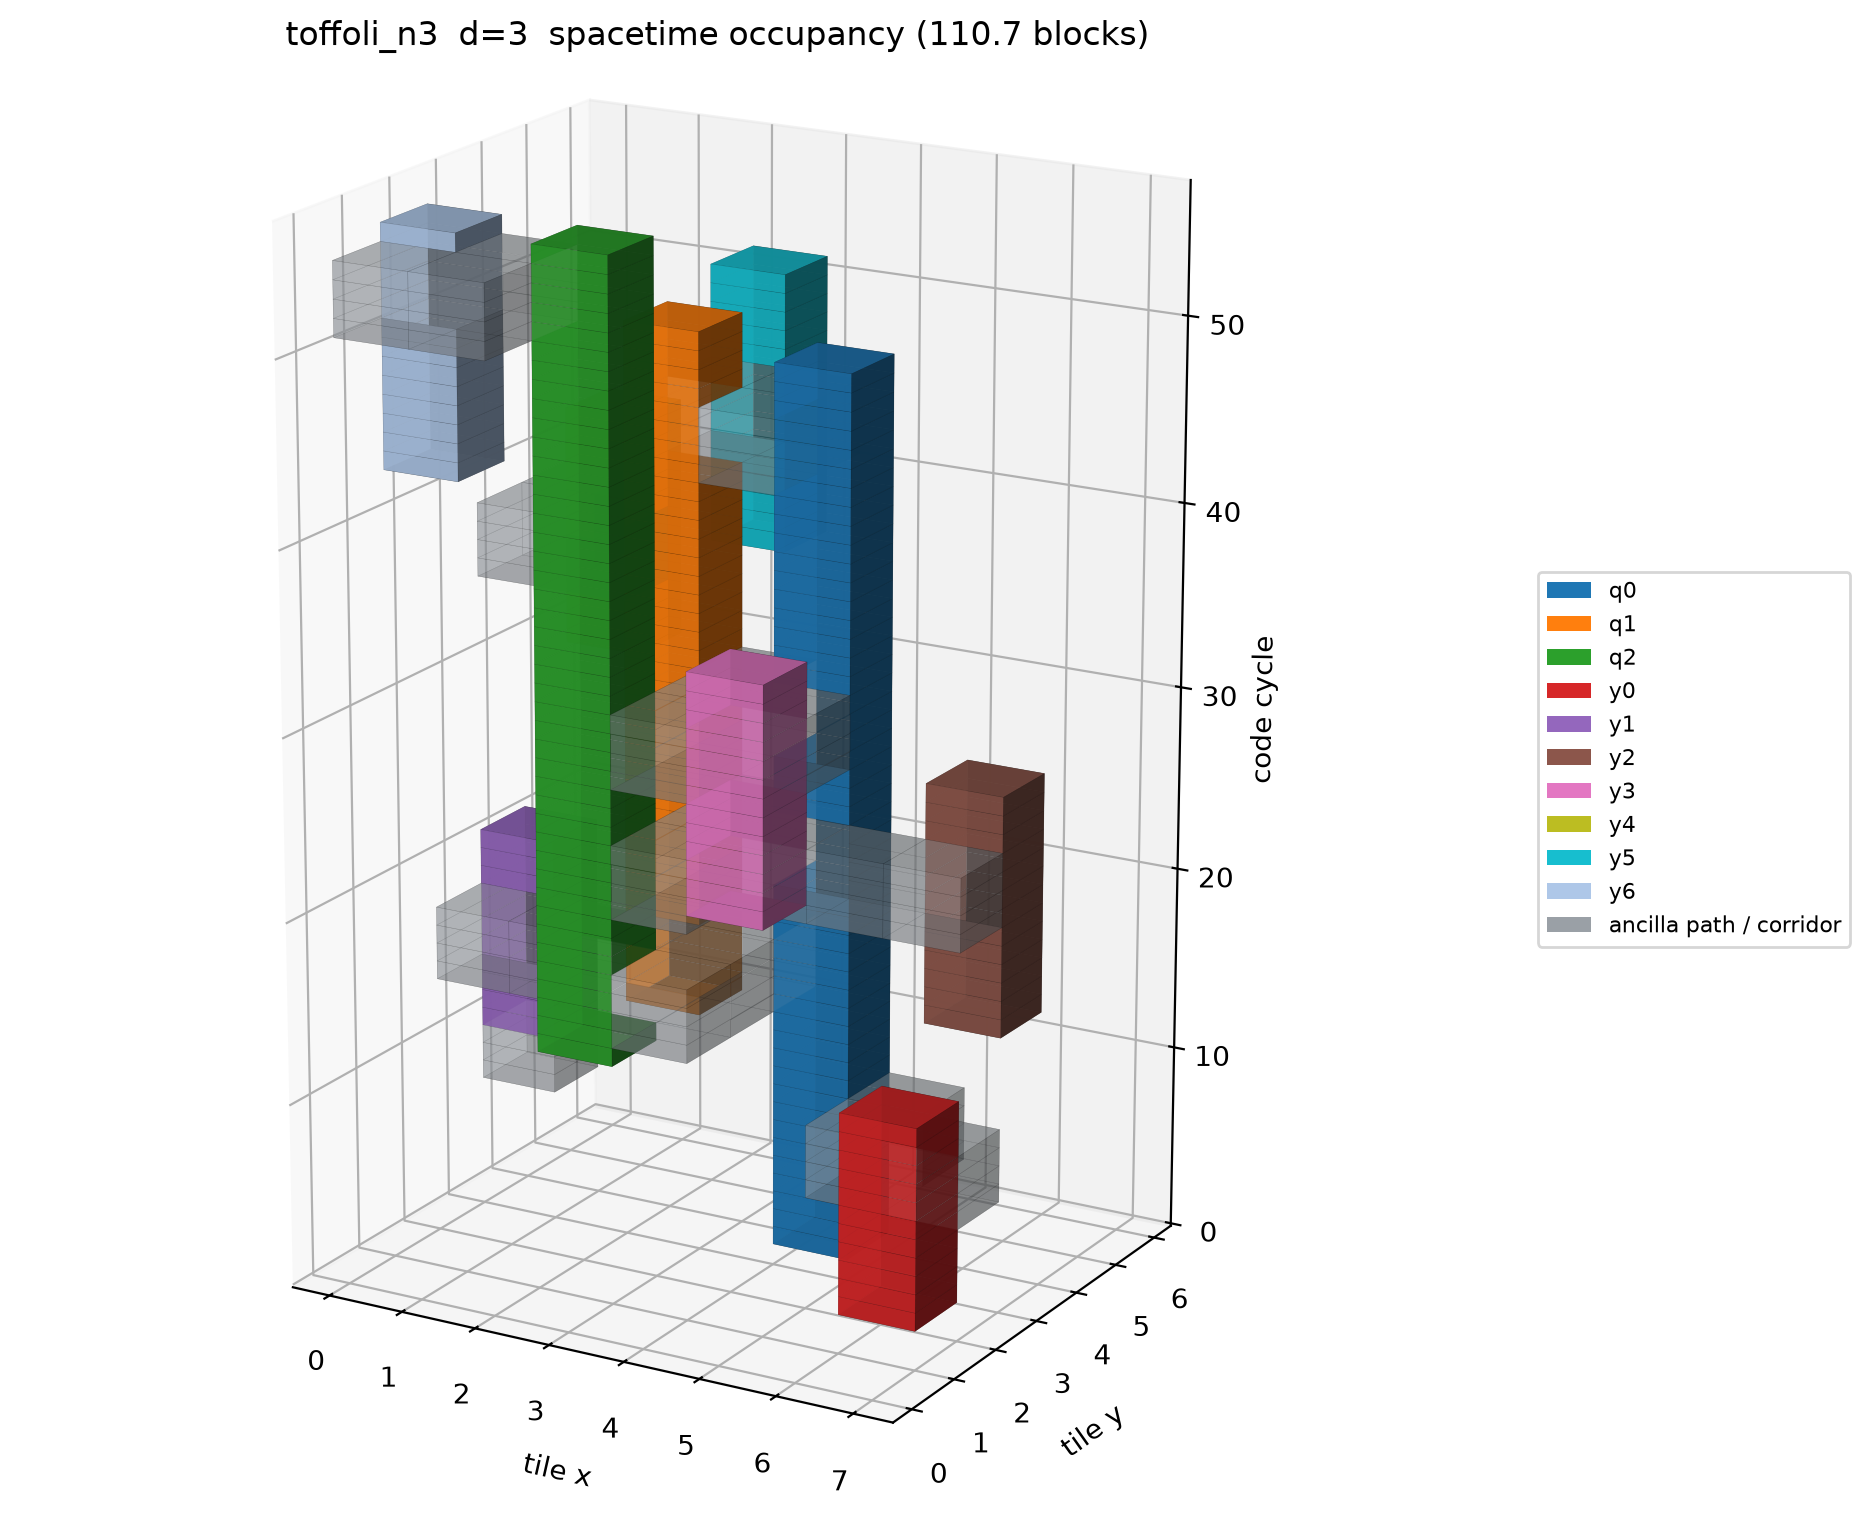

In [5]:
from circls.metrics.experiment_stats import experiment_stats
from render_spacetime import render
from nb_helpers import save_routing

print(save_routing(cp3, steps, "data/5_toffoli_n3_placement_routing.json"))
stats = experiment_stats(cp3.experiment, cp3.circuit)
png, js, _ = render(stats, cp3.placement, "toffoli_n3", str(HERE / "figures"), distance=3)
import shutil
shutil.move(str(HERE / "figures" / "toffoli_n3_schedule.json"),
            str(HERE / "data" / "5_toffoli_n3_schedule.json"))
png2 = str(HERE / "figures" / "5_toffoli_n3_spacetime.png")
shutil.move(png, png2); png = png2
print("3D structure:", pathlib.Path(png).name, f"({stats.volume_blocks:.1f} blocks)")
from IPython.display import Image, display
display(Image(png, width=640))

## 6. TQEC block-graph export (rotatable)

In [6]:
import os
from export_blockgraph_auto import auto_export
auto_export(cp3, "toffoli_n3", HERE / "blockgraph",
            tqec_python=os.environ.get("TQEC_PYTHON"))
BG = HERE / "blockgraph"
from IPython.display import IFrame, display
hits = sorted(BG.glob("*_blockgraph.html"))
if hits:
    print(f"-> blockgraph/{hits[0].name} -- drag to rotate "
          f"(the .dae loads into tqec / SketchUp)")
    display(IFrame("blockgraph/" + hits[0].name, width=760, height=480))
else:
    print()
    print((BG / "gap_note.txt").read_text())

wrote toffoli_n3_blockstructure.json: 72 cubes, 74 pipes, 22 pinned walls, 7 Y half-cube(s), 9 layers


NOT EXPORTED -- 32 distinct seam-side variant(s) tried; last: NOT EXPORTED: no ZXCube assignment satisfies the wall rules with the protocol's pinned faces -- expressibility gap.
(full search log: blockgraph/export_log.txt)

toffoli_n3 does not map onto TQEC's ZXCube vocabulary under a
one-cube-per-tile reading of the CircLS schedule: the Y-state
approximation consumes seven |Y>-initialized ancilla patches, and no
wall assignment satisfies the ZXCube rules together with the merge
pins -- robustly: the exporter searched 32 seam-side contact variants
and every one fails the wall rules (see export_log.txt).  Same
vocabulary corner as twistedghz_8; tqec's tracker has it open too
("Y cube is not implemented" in the fixed-boundary builder, issue
#967).  The geometry is recorded in toffoli_n3_blockstructure.json.



## 7. stim circuits: clean and noisy, d=3, 5, 7

In [7]:
from noise_inject import inject_uniform_noise
P_NOISY = 1e-3
circuits = {}
for d in (3, 5, 7):
    cp = cp3 if d == 3 else compile_d(d)
    clean = cp.circuit
    circuits[d] = clean
    (HERE / "stim" / f"d{d}").mkdir(exist_ok=True)
    pathlib.Path(f"stim/d{d}/7_toffoli_n3_clean.stim").write_text(str(clean))
    pathlib.Path(f"stim/d{d}/7_toffoli_n3_noisy_p1e-3.stim").write_text(
        str(inject_uniform_noise(clean, P_NOISY)))
    print(f"d={d}: {clean.num_qubits} qubits, {clean.num_detectors} detectors, "
          f"{clean.num_observables} observables")

d=3: 643 qubits, 2265 detectors, 5 observables


d=5: 1627 qubits, 9594 detectors, 5 observables


d=7: 3043 qubits, 24835 detectors, 5 observables


## 8. Measured logical error rate of the CircLS-compiled circuits

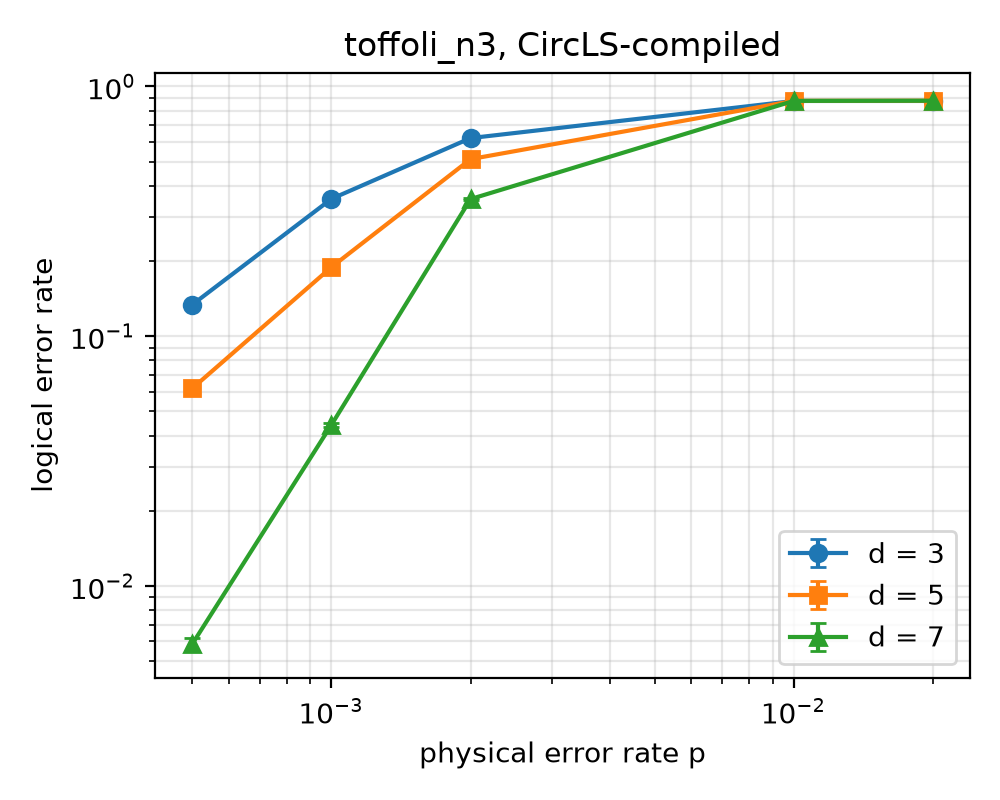

In [8]:
from ler_sampler import measure_ler
from nb_helpers import save_ler_points, plot_ler

PS = [5e-4, 1e-3, 2e-3, 1e-2, 2e-2]
WORKERS = 32     # parallel sampling processes -- set to your machine
points = {(d, p): measure_ler(inject_uniform_noise(clean, p), workers=WORKERS)
          for d, clean in circuits.items() for p in PS}
save_ler_points(points, "data/8_toffoli_n3_ler_points.json")
plot_ler(points, PS, "toffoli_n3, CircLS-compiled", "figures/8_toffoli_n3_ler.png")
from IPython.display import Image, display
display(Image("figures/8_toffoli_n3_ler.png", width=560))